IMPORTING DEPENDENCIES

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from librosa import load, feature
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Flatten, Input, TimeDistributed, Attention
from tensorflow.keras.models import Sequential, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt  
from sklearn.model_selection import GridSearchCV
from tensorflow.nn import softmax


In [2]:
# pip install lightgbm


LOADING DATA AND EXTRACTING FEATURES (using MFCCs) and FORMING A DATAFRAME

In [3]:
import os
from librosa import load, feature
import pandas as pd

def create_dataset(folder_path):
  emotions = {1: "neutral", 2: "calm", 3: "happy", 4: "sad", 5: "angry", 6: "fear", 7: "disgust", 8: "surprise"}
  data = []
  for filename in os.listdir(folder_path):
    # Extract emotion label
    emotion_code = int(filename.split("-")[2])
    emotion = emotions[emotion_code]
    
    # Load audio path
    audio_path = os.path.join(folder_path, filename)
    
    # Extract MFCCs
    audio, sr = load(audio_path)
    mfcc = feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    mfcc_scaled = np.mean(mfcc.T, axis=0)

    data.append({
      "audio_path": audio_path,
      "features": mfcc_scaled.tolist(),  # Convert to list for DataFrame
      "emotion": emotion
    })

  df = pd.DataFrame(data)
  return df

# Replace "path/to/your/folder" with your actual folder path
df = create_dataset("audio_speech_actors_01-24\\All audios till 10")

# Print the dataset
print(df.head())




                                          audio_path  \
0  audio_speech_actors_01-24\All audios till 10\0...   
1  audio_speech_actors_01-24\All audios till 10\0...   
2  audio_speech_actors_01-24\All audios till 10\0...   
3  audio_speech_actors_01-24\All audios till 10\0...   
4  audio_speech_actors_01-24\All audios till 10\0...   

                                            features  emotion  
0  [-697.7926025390625, 54.89004135131836, 0.6634...  neutral  
1  [-650.7108764648438, 54.47730255126953, -9.090...  neutral  
2  [-614.7391357421875, 56.70819091796875, -2.685...  neutral  
3  [-695.8502807617188, 42.934261322021484, -7.27...  neutral  
4  [-713.4334716796875, 68.3609390258789, 7.98917...  neutral  


In [4]:
df

,audio_path,features,emotion
0,audio_speech_actors_01-24\All audios till 10\0...,"[-697.7926025390625, 54.89004135131836, 0.6634...",neutral
1,audio_speech_actors_01-24\All audios till 10\0...,"[-650.7108764648438, 54.47730255126953, -9.090...",neutral
2,audio_speech_actors_01-24\All audios till 10\0...,"[-614.7391357421875, 56.70819091796875, -2.685...",neutral
3,audio_speech_actors_01-24\All audios till 10\0...,"[-695.8502807617188, 42.934261322021484, -7.27...",neutral
4,audio_speech_actors_01-24\All audios till 10\0...,"[-713.4334716796875, 68.3609390258789, 7.98917...",neutral
...,...,...,...
1435,audio_speech_actors_01-24\All audios till 10\0...,"[-597.7596435546875, 33.127742767333984, -17.4...",surprise
1436,audio_speech_actors_01-24\All audios till 10\0...,"[-514.4945678710938, 43.662452697753906, -2.89...",surprise
1437,audio_speech_actors_01-24\All audios till 10\0...,"[-536.5254516601562, 24.84990882873535, -13.78...",surprise
1438,audio_speech_actors_01-24\All audios till 10\0...,"[-525.8436889648438, 33.495296478271484, -11.4...",surprise


In [5]:
df.head()

,audio_path,features,emotion
0,audio_speech_actors_01-24\All audios till 10\0...,"[-697.7926025390625, 54.89004135131836, 0.6634...",neutral
1,audio_speech_actors_01-24\All audios till 10\0...,"[-650.7108764648438, 54.47730255126953, -9.090...",neutral
2,audio_speech_actors_01-24\All audios till 10\0...,"[-614.7391357421875, 56.70819091796875, -2.685...",neutral
3,audio_speech_actors_01-24\All audios till 10\0...,"[-695.8502807617188, 42.934261322021484, -7.27...",neutral
4,audio_speech_actors_01-24\All audios till 10\0...,"[-713.4334716796875, 68.3609390258789, 7.98917...",neutral


DATA PREPROCESSING

In [6]:
df['emotion'].value_counts()

emotion
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64

In [7]:
# Assuming your dataset is stored in a Pandas DataFrame named 'df'
# Separate features, labels, and audio paths
X = df["features"].tolist()  # Convert features column to list
y = df["emotion"]
audio_paths = df["audio_path"].tolist()

# Scale features (assuming features are numerical)
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
X_train = np.expand_dims(X_train, axis=1)  # Add a dimension for timesteps (axis=1)
X_test = np.expand_dims(X_test, axis=1)


encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

(1152, 20)


TRAINING RNN MODEL

In [8]:
# Define the RNN model (replace with your desired architecture)
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(1, len(X[0]))))
model.add(LSTM(32))
model.add(Dense(len(set(y)), activation="softmax"))  # Output for all unique emotions

# Compile the model
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train the model
history=model.fit(X_train, y_train_encoded, epochs=100, validation_data=(X_test, y_test_encoded),verbose=1)

# Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, y_test_encoded)
print("Test Accuracy:", accuracy)


d:\JKLU\Academics\2nd Year\4th Semester\ML\Project\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.1664 - loss: 2.0679 - val_accuracy: 0.2292 - val_loss: 2.0346
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2189 - loss: 2.0145 - val_accuracy: 0.2535 - val_loss: 1.9583
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2709 - loss: 1.9258 - val_accuracy: 0.2500 - val_loss: 1.8902
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2824 - loss: 1.8636 - val_accuracy: 0.3021 - val_loss: 1.8296
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3252 - loss: 1.7935 - val_accuracy: 0.3194 - val_loss: 1.7701
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3138 - loss: 1.7554 - val_accuracy: 0.3229 - val_loss: 1.7177
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3765 - loss: 1.6557 - val_accuracy: 0.3542 - val_loss: 1.6632
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4130 - loss: 1.5696 - val_accuracy: 0.3924 - 

PREDICTION ON RNN MODEL

In [9]:
pred_list=[]
pred_audio_file='audio_speech_actors_01-24\\All audios till 10\\03-01-08-02-02-02-20.wav'
audio, sr = load(pred_audio_file)
mfcc = feature.mfcc(y=audio, sr=sr, n_mfcc=20)
mfcc_scaled = np.mean(mfcc.T, axis=0)

# mfcc_scaled

pred_list.append(mfcc_scaled)

pred_data=pd.DataFrame(list(zip(pred_list)), columns=['MFCC feature'])
pred_data
# pred_list   

,MFCC feature
0,"[-597.75964, 33.127743, -17.432682, 3.7646341,..."


In [ ]:
model.save('saved_model.h5') 


In [ ]:
# Assuming you have already trained your RNN model and stored it in a variable called 'model' 
# Save the trained model 
def predict_emotion(audio_path, model):
    # Load audio file 
    audio, sr = load(audio_path) 
    # Extract MFCCs 

    mfcc = feature.mfcc(y=audio, sr=sr, n_mfcc=20) 

    mfcc_scaled = np.mean(mfcc.T, axis=0) 
    # Scale features 
    mfcc_scaled = scaler.transform([mfcc_scaled]) 
    # Reshape features for model input 

    mfcc_scaled = np.expand_dims(mfcc_scaled, axis=1) 
    # Predict emotion 

    prediction = model.predict(mfcc_scaled) 
    # Decode predicted emotion 

    predicted_emotion = encoder.inverse_transform([np.argmax(prediction)]) 
    return predicted_emotion[0] 
# Example usage 

audio_path = "TEST10.wav" 

model = keras.models.load_model('saved_model.h5') 

predicted_emotion = predict_emotion(audio_path, model) 

print("Predicted Emotion:", predicted_emotion) 

 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Predicted Emotion: disgust


TRAINING GRU MODEL

In [12]:
# Define the RNN model (replace with your desired architecture)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
model = Sequential()
model.add(GRU(64,return_sequences=True, input_shape=(1, len(X[0]))))
model.add(GRU(32))
model.add(Dense(len(set(y)), activation="softmax"))  # Output for all unique emotions

# Compile the model
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train the model
history=model.fit(X_train, y_train_encoded, epochs=100, validation_data=(X_test, y_test_encoded),verbose=1)

# Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, y_test_encoded)
print("Test Accuracy:", accuracy)


Epoch 1/100


d:\JKLU\Academics\2nd Year\4th Semester\ML\Project\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2176 - loss: 2.0368 - val_accuracy: 0.2674 - val_loss: 1.9431
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2699 - loss: 1.9209 - val_accuracy: 0.2882 - val_loss: 1.8360
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3049 - loss: 1.8010 - val_accuracy: 0.3299 - val_loss: 1.7488
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3330 - loss: 1.7232 - val_accuracy: 0.3681 - val_loss: 1.6664
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3518 - loss: 1.6622 - val_accuracy: 0.3958 - val_loss: 1.5957
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4046 - loss: 1.5584 - val_accuracy: 0.4167 - val_loss: 1.5349
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4200 - loss: 1.5111 - val_accuracy: 0.4444 - val_loss: 1.4963
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4406 - loss: 1.4909 - val_accuracy: 0.4757 - val_loss: 1.

In [ ]:
model.save('saved_model.h5') 


In [ ]:
# Assuming you have already trained your RNN model and stored it in a variable called 'model' 
# Save the trained model 
def predict_emotion(audio_path, model):
    # Load audio file 
    audio, sr = load(audio_path) 
    # Extract MFCCs 

    mfcc = feature.mfcc(y=audio, sr=sr, n_mfcc=20) 

    mfcc_scaled = np.mean(mfcc.T, axis=0) 
    # Scale features 
    mfcc_scaled = scaler.transform([mfcc_scaled]) 
    # Reshape features for model input 

    mfcc_scaled = np.expand_dims(mfcc_scaled, axis=1) 
    # Predict emotion 

    prediction = model.predict(mfcc_scaled) 
    # Decode predicted emotion 

    predicted_emotion = encoder.inverse_transform([np.argmax(prediction)]) 
    return predicted_emotion[0] 
# Example usage 

audio_path = "TEST10.wav" 

model = keras.models.load_model('saved_model.h5') 

predicted_emotion = predict_emotion(audio_path, model) 

print("Predicted Emotion:", predicted_emotion) 

 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Predicted Emotion: disgust


TRAINING A ATTENTION BASED RNN MODEL

In [15]:

# from tensorflow import keras
# from tensorflow.keras.layers import LSTM, Dense, Conv1D, MaxPooling1D,Reshape, Flatten, Input, TimeDistributed, Attention

# def create_attention_model(input_shape):
#   """
#   Creates an Attention-based RNN model for audio emotion classification.

#   Args:
#       input_shape: A tuple representing the shape of the input features (e.g., (timesteps, features)).

#   Returns:
#       A compiled Keras model.
#   """

#   # Encoder (LSTM with Attention)
#   inputs = Input(shape=input_shape)
#   encoded = LSTM(64, return_sequences=True)(inputs)  # First LSTM layer
# #   attention_weights = TimeDistributed(Dense(1, activation='tanh'))(encoded)  # Attention weights calculation
#   attention_weights = Reshape((1, 64))(TimeDistributed(Dense(1, activation='tanh'))(encoded))
#   attention_weights = Attention()([encoded, attention_weights])  # Attention layer (remove use_bias)
#   encoded = LSTM(32)(attention_weights)  # Second LSTM layer with attention-weighted features

#   # Decoder (Dense output layer)
#   outputs = Dense(len(set(y)), activation='softmax')(encoded)  # Output layer for all emotions

#   # Model creation and compilation
#   model = keras.Model(inputs=inputs, outputs=outputs)
#   model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#   return model


In [16]:
# model = create_attention_model(X_train.shape[1:])


In [17]:
# history = model.fit(X_train, y_train_encoded, epochs=100, validation_data=(X_test, y_test_encoded), verbose=1)


In [18]:
# loss, accuracy = model.evaluate(X_test, y_test)
# print("Test Accuracy:", accuracy)

In [19]:
# Assuming your dataset is stored in a Pandas DataFrame named 'df'
# Separate features, labels, and audio paths
X = df["features"].tolist()  # Convert features column to list
y = df["emotion"]
audio_paths = df["audio_path"].tolist()

# Scale features (assuming features are numerical)
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
X_train = np.expand_dims(X_train, axis=1)  # Add a dimension for timesteps (axis=1)
X_test = np.expand_dims(X_test, axis=1)


encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

(1152, 20)


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

# Hyperparameters (adjust as needed)
max_features = 10000  # Maximum number of words in the vocabulary
max_len = 200  # Maximum sentence length

# Embedding layer (convert integers to vectors)
embedding_dim = 128  # Dimensionality of word embeddings
model = Sequential()
model.add(Embedding(max_features, embedding_dim, input_length=max_len))

# GRU layer
model.add(GRU(units=128, return_sequences=True))  # Adjust units as needed

# Final dense layer for classification
model.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
# model.fit(X_train, y_train, epochs=10, batch_size=32)
history=model.fit(X_train, y_train_encoded, epochs=100, validation_data=(X_test, y_test_encoded),verbose=1)


# ... rest of your code for evaluation and prediction


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
import numpy as np

# Assuming your dataset is stored in a Pandas DataFrame named 'df'

# Separate features and labels
X = df["features"].tolist()  # Convert features column to list
y = df["emotion"]

# Scale features (assuming features are numerical)
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
# X_train = np.expand_dims(X_train, axis=1)  # Add a dimension for timesteps (axis=1)
# X_test = np.expand_dims(X_test, axis=1)

# No label encoding needed for numerical features

# Hyperparameters (adjust as needed)
max_len = 200  # Maximum sequence length (assuming features represent a sequence)
num_units = 128  # Number of units in the GRU layer (adjustable)
num_classes = len(np.unique(y_train))  # Number of unique emotions (classes)

# Create the GRU model
model = Sequential()
model.add(GRU(units=num_units, return_sequences=True, input_shape=(X_train.shape[0], X_train.shape[1]), activation='relu'))  # Specify input shape
model.add(GRU(units=num_units))  # Second GRU layer
model.add(Dense(8, activation='softmax'))  # Final layer with correct number of units and softmax activation

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=1)

# ... rest of your code for evaluation and prediction


VISUALISING THE ACCURACY OF RNN MODEL WITH INCRESE IN NUMBER OF EPOCHES

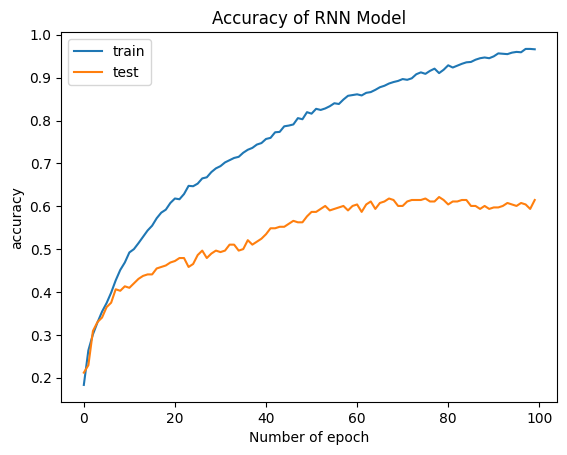

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy of RNN Model')
plt.ylabel('accuracy')
plt.xlabel('Number of epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
accuracy_df = pd.DataFrame({
  "Epoch": range(1, len(history.history['accuracy']) + 1),  # Epochs start from 1
  "Training Accuracy": history.history['accuracy'],
  "Validation Accuracy": history.history.get('val_accuracy', [])  # Include validation accuracy if available
})

# Print or use the accuracy_df as needed
accuracy_df

,Epoch,Training Accuracy,Validation Accuracy
0,1,0.183160,0.211806
1,2,0.263889,0.229167
2,3,0.301215,0.309028
3,4,0.328993,0.329861
4,5,0.354167,0.340278
...,...,...,...
95,96,0.960069,0.600694
96,97,0.959201,0.607639
97,98,0.967014,0.604167
98,99,0.967014,0.593750


TRAINING ANN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics

In [ ]:
y = np.array(df['emotion'].tolist())
y=np.array(pd.get_dummies(y))

In [ ]:
y.shape

(1440, 8)

In [ ]:
# number of classes
num_labels=y.shape[1]
num_labels

8

In [ ]:
# Creating a ANN model with 3 layers
# why dropout is used??
model_ANN=Sequential()
###first layer
model_ANN.add(Dense(100,input_shape=(40,)))
model_ANN.add(Activation('relu'))
model_ANN.add(Dropout(0.5))
###second layer
model_ANN.add(Dense(200))
model_ANN.add(Activation('relu'))
model_ANN.add(Dropout(0.5))
###third layer
model_ANN.add(Dense(100))
model_ANN.add(Activation('relu'))
model_ANN.add(Dropout(0.5))
###final layer
model_ANN.add(Dense(num_labels))
model_ANN.add(Activation('softmax')) #solftmax as it is a multiclass classification problem

d:\JKLU\Academics\2nd Year\4th Semester\ML\Project\.conda\Lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_ANN.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,208 (176.59 KB)

 Trainable params: 45,208 (176.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_ANN.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')

In [ ]:
history=model_ANN.fit(X_train, y_train_encoded, epochs=100, validation_data=(X_test, y_test_encoded),verbose=1)

OTHER REGRESSION AND CLASSIFICATION MODELS

In [ ]:
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb
# Assuming your dataset is stored in a Pandas DataFrame named 'df'

# Separate features, labels, and audio paths (assuming features are numerical
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)  # Flatten features
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)
# Define and train various models (modify hyperparameters as needed)
models = {}
models["SVC"] = SVC()
models["RandomForestClassifier"] = RandomForestClassifier(n_estimators=100)
models["GradientBoostingClassifier"] = GradientBoostingClassifier(n_estimators=100)
models["KNeighborsClassifier"] = KNeighborsClassifier(n_neighbors=5)
models["MLPClassifier"] = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(100,))
models["BaggingClassifier"] = BaggingClassifier( n_estimators=100)
models["AdaBoostClassifier"] = AdaBoostClassifier(n_estimators=100)
models['LogisticRegression']=LogisticRegression()
models['LightGBM']=lgb.LGBMClassifier()
models['XGBoost']=xgb.XGBClassifier()
# Train and evaluate each model
results = []
for name, model in models.items():
  model.fit(X_train_reshaped, y_train_encoded)
  y_pred = model.predict(X_test_reshaped)
  accuracy = accuracy_score(y_test_encoded, y_pred)
  precision = precision_score(y_test_encoded, y_pred, average='weighted')  # Weighted precision
  results.append((name, accuracy, precision))

# Create DataFrame with results
df_results = pd.DataFrame(results, columns=["Model Name", "Accuracy", "Precision"])


d:\JKLU\Academics\2nd Year\4th Semester\ML\Project\.conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000705 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1152, number of used features: 20
[LightGBM] [Info] Start training from score -2.107612
[LightGBM] [Info] Start training from score -2.012302
[LightGBM] [Info] Start training from score -1.967850
[LightGBM] [Info] Start training from score -1.949388
[LightGBM] [Info] Start training from score -2.012302
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.025374
[LightGBM] [Info] Start training from score -2.005830
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [ ]:
df_results

,Model Name,Accuracy,Precision
0,SVC,0.597222,0.652419
1,RandomForestClassifier,0.559028,0.566041
2,GradientBoostingClassifier,0.472222,0.487854
3,KNeighborsClassifier,0.590278,0.596983
4,MLPClassifier,0.579861,0.587608
5,BaggingClassifier,0.545139,0.552163
6,AdaBoostClassifier,0.322917,0.295898
7,LogisticRegression,0.437500,0.456167
8,LightGBM,0.593750,0.597380
9,XGBoost,0.552083,0.552348


VISUALISING OTHER MODELS THORUGH GRAPHS

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'SVC'),
  Text(1, 0, 'RandomForestClassifier'),
  Text(2, 0, 'GradientBoostingClassifier'),
  Text(3, 0, 'KNeighborsClassifier'),
  Text(4, 0, 'MLPClassifier'),
  Text(5, 0, 'BaggingClassifier'),
  Text(6, 0, 'AdaBoostClassifier'),
  Text(7, 0, 'LogisticRegression'),
  Text(8, 0, 'LightGBM'),
  Text(9, 0, 'XGBoost')])

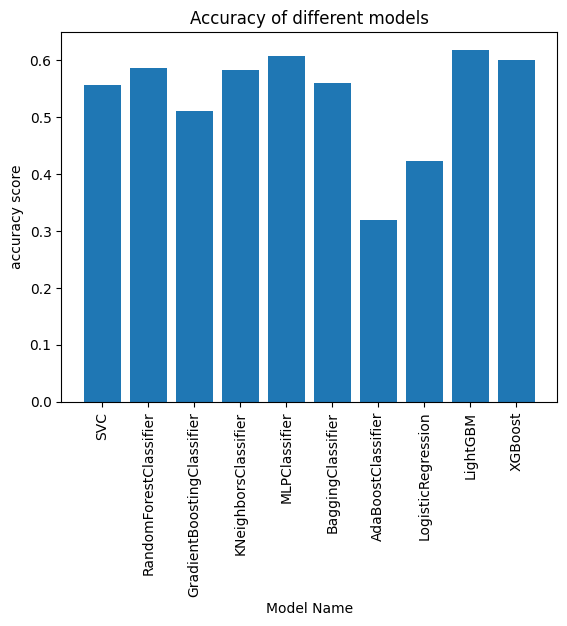

In [ ]:
plt.bar(df_results['Model Name'], df_results['Accuracy'])
plt.xlabel("Model Name")
plt.ylabel("accuracy score")
plt.title("Accuracy of different models")
plt.xticks(rotation=90)

ACCURACY AND PRECISION OF OTHER MODELS

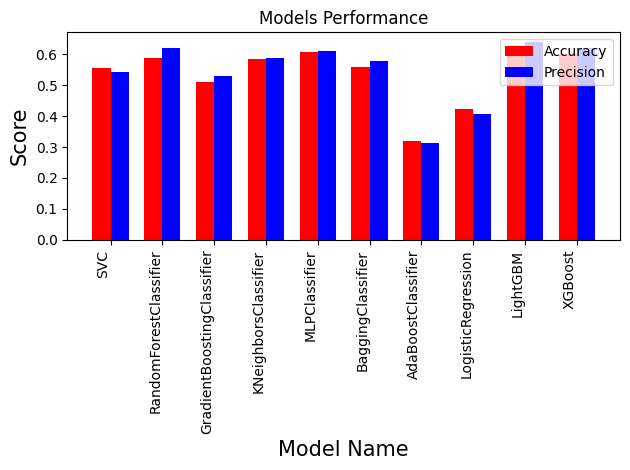

In [ ]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df_results'

fig, ax = plt.subplots()  # Create a single subplot for stacked bars

# Stacked Bar Plot (using width parameter)
bar_width = 0.35  # Adjust bar width as needed

# Accuracy Bar
ax.bar(df_results['Model Name'], df_results['Accuracy'], bar_width, label='Accuracy', color='red')

# Precision Bar (shifted slightly on x-axis)
ax.bar([pos + bar_width for pos in df_results.index], df_results['Precision'], bar_width, label='Precision', color='blue')

ax.set_title("Models Performance")
ax.set_xlabel("Model Name", fontsize=15)
ax.set_ylabel("Score", fontsize=15)
ax.set_xticks([pos + bar_width / 2 for pos in df_results.index])
ax.set_xticklabels(df_results['Model Name'], rotation=90, ha='right')  # Rotate x-axis labels
ax.legend()  # Add legend

plt.tight_layout()
plt.show()


In [ ]:
X_train.shape
y_train.shape
y_test.shape

(288,)

In [ ]:
df

,audio_path,features,emotion
0,audio_speech_actors_01-24\All audios till 10\0...,"[-697.7926025390625, 54.89004135131836, 0.6634...",neutral
1,audio_speech_actors_01-24\All audios till 10\0...,"[-650.7108764648438, 54.47730255126953, -9.090...",neutral
2,audio_speech_actors_01-24\All audios till 10\0...,"[-614.7391357421875, 56.70819091796875, -2.685...",neutral
3,audio_speech_actors_01-24\All audios till 10\0...,"[-695.8502807617188, 42.934261322021484, -7.27...",neutral
4,audio_speech_actors_01-24\All audios till 10\0...,"[-713.4334716796875, 68.3609390258789, 7.98917...",neutral
...,...,...,...
1435,audio_speech_actors_01-24\All audios till 10\0...,"[-597.7596435546875, 33.127742767333984, -17.4...",surprise
1436,audio_speech_actors_01-24\All audios till 10\0...,"[-514.4945678710938, 43.662452697753906, -2.89...",surprise
1437,audio_speech_actors_01-24\All audios till 10\0...,"[-536.5254516601562, 24.84990882873535, -13.78...",surprise
1438,audio_speech_actors_01-24\All audios till 10\0...,"[-525.8436889648438, 33.495296478271484, -11.4...",surprise


In [ ]:
X_hmm=df.drop(['audio_path','emotion'], axis=1)
y_hmm=df['emotion']
X_train_hmm, X_test_hmm, y_train_hmm, y_test_hmm = train_test_split(X_hmm, y_hmm, test_size=0.5)
print(X_hmm.shape[0], X_train_hmm.shape[0], X_test_hmm.shape[0])

1440 720 720


In [ ]:

from hmmlearn import hmm
from tensorflow.keras.preprocessing.sequence import pad_sequences # type: ignore


# Define the number of hidden states in the HMM (experiment with different values)
n_components = 4

# Create an HMM model
model = hmm.GaussianHMM(n_components=n_components)


# Assuming X_train_hmm is your training data with variable-length sequences
max_len = 100  # Define the desired maximum sequence length

# Pad sequences to the maximum length
X_train_hmm_padded = pad_sequences(X_train_hmm, maxlen=max_len, padding='post')

# Train your HMM model using X_train_hmm_padded
model.fit(X_train_hmm_padded, y_train_hmm)


# Evaluate the model on the testing data (optional)
# You can use metrics like accuracy or log-likelihood

# Predict emotions for new data (replace with actual new features)
predicted_emotions = model.predict(X_test_hmm)

print("Predicted emotions:", predicted_emotions)
